# EDA — Post-Hypothesis Visualizations

This notebook picks up where the hypothesis testing left off.
We visualize the features that turned out to be statistically
significant for differentiating **Won** vs **Churned** customers.

All plots use the `model_ready_dataset.csv` (feature-engineered table).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# load data
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

df = pd.read_csv(project_root / "data" / "processed" / "model_ready_dataset.csv")
df = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
print(f"Rows: {len(df)}  (Won={len(df[df.Prospect_Outcome=='Won'])}, Churned={len(df[df.Prospect_Outcome=='Churned'])})")

Rows: 113894  (Won=101226, Churned=12668)


---
## 1 · Box Plots — Top Numeric Features by Churn Status

Showing the distributions of the most impactful numeric features
split by outcome. These were all statistically significant in our
hypothesis tests.

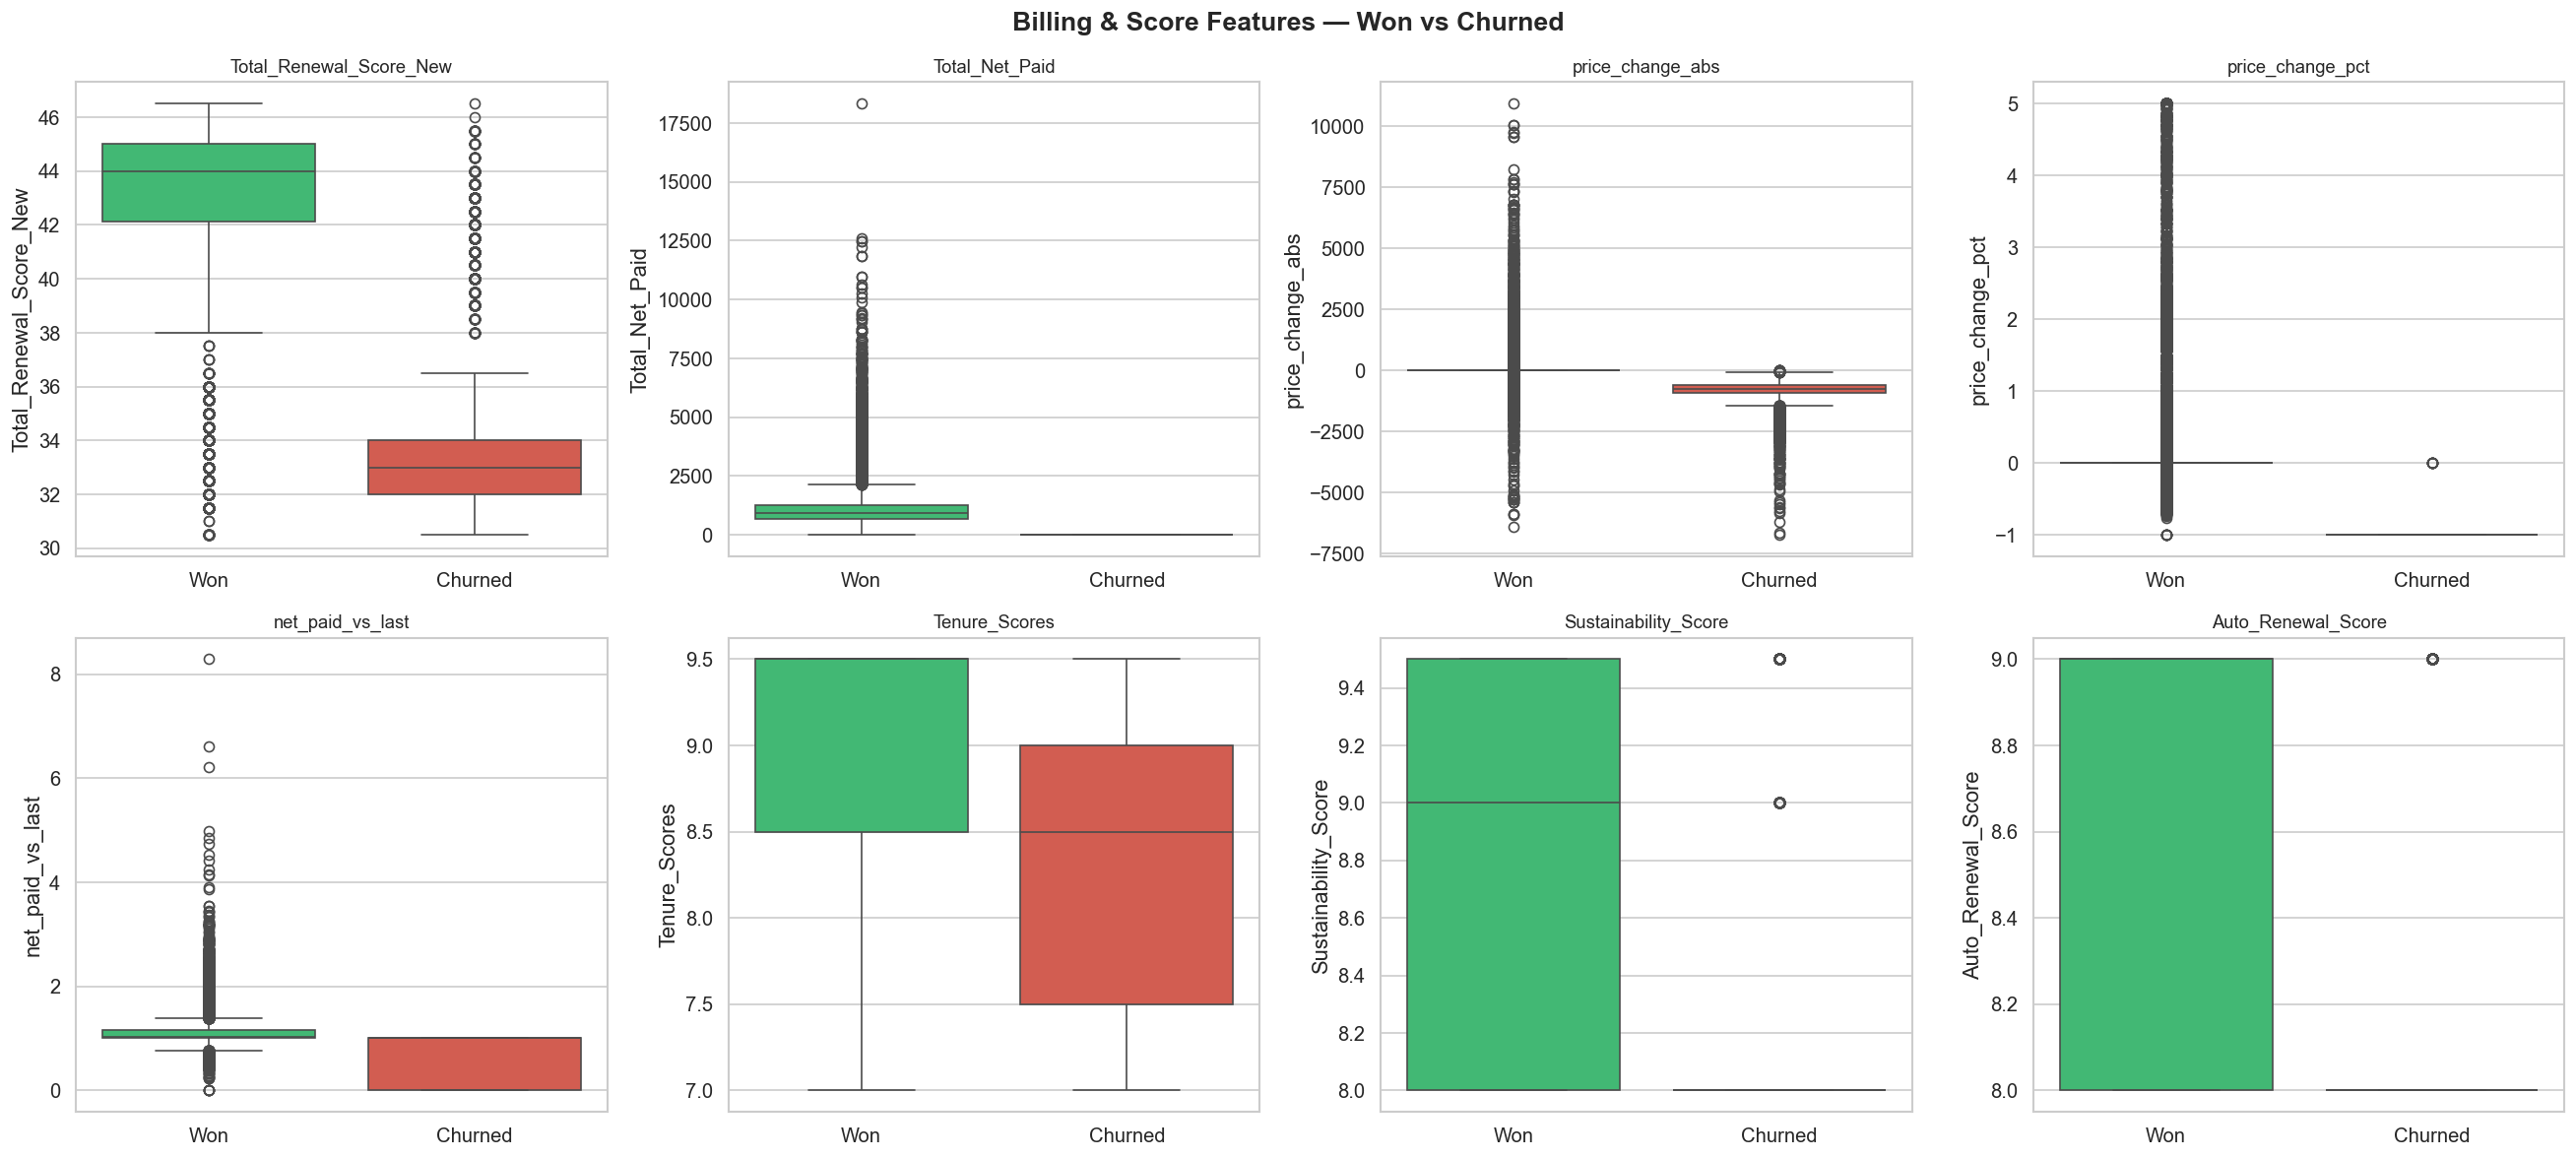

In [2]:
# --- billing & score features ---
billing_feats = [
    "Total_Renewal_Score_New", "Total_Net_Paid",
    "price_change_abs", "price_change_pct",
    "net_paid_vs_last", "Tenure_Scores",
    "Sustainability_Score", "Auto_Renewal_Score",
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Billing & Score Features — Won vs Churned", fontsize=16, fontweight="bold")

for ax, feat in zip(axes.flatten(), billing_feats):
    sns.boxplot(data=df, x="Prospect_Outcome", y=feat, ax=ax,
                order=["Won", "Churned"], palette={"Won": "#2ecc71", "Churned": "#e74c3c"})
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

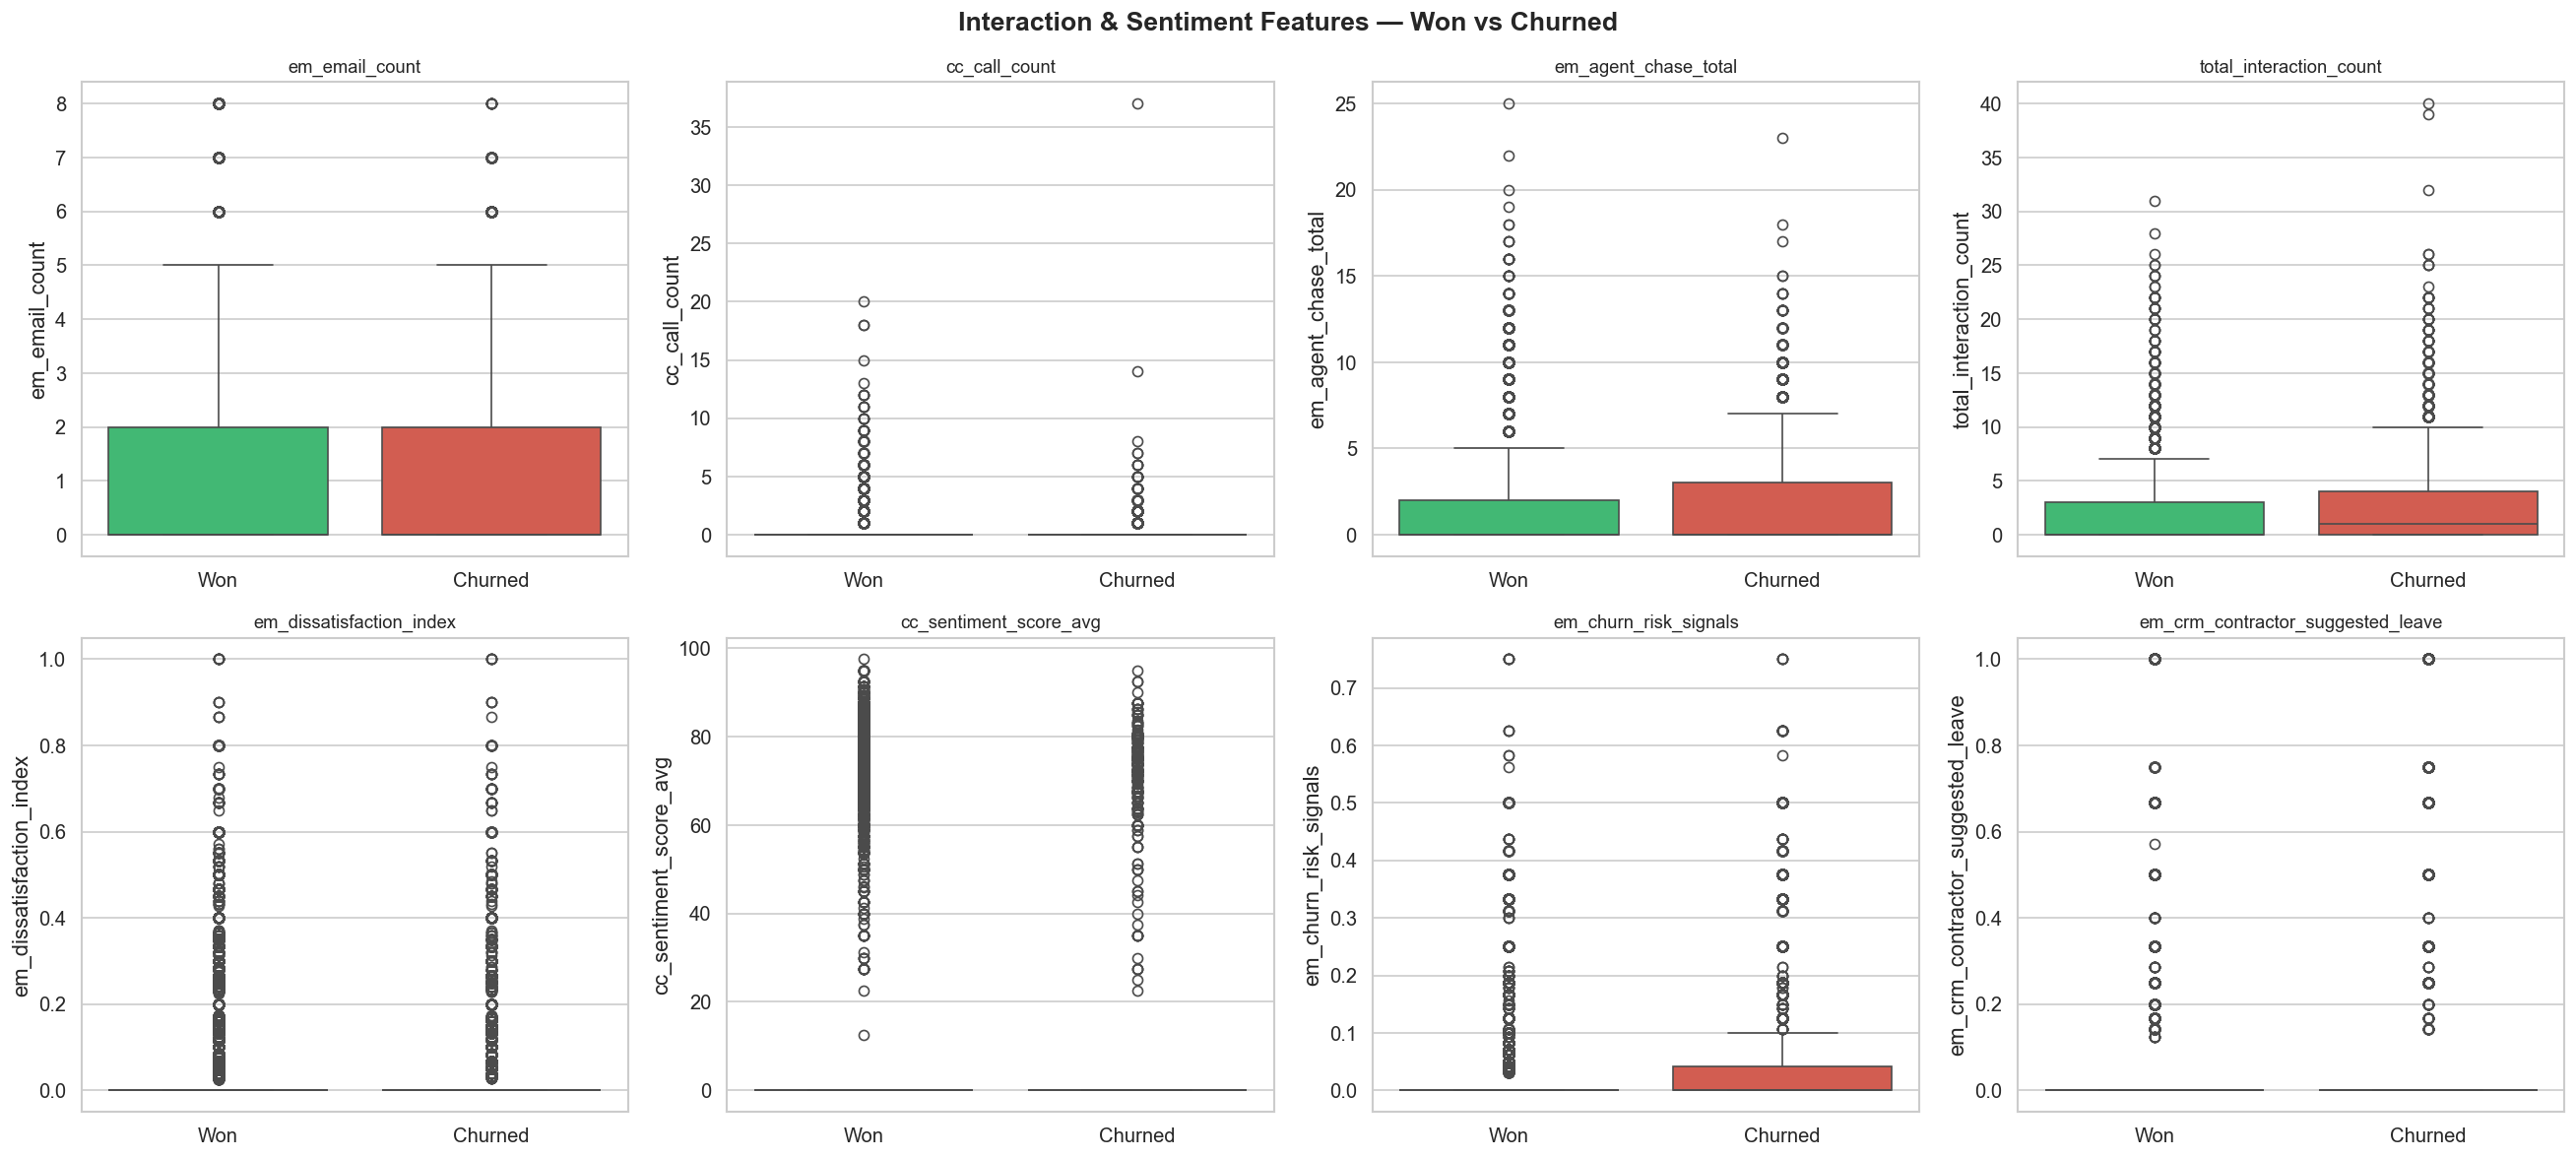

In [3]:
# --- interaction + sentiment features ---
interaction_feats = [
    "em_email_count", "cc_call_count",
    "em_agent_chase_total", "total_interaction_count",
    "em_dissatisfaction_index", "cc_sentiment_score_avg",
    "em_churn_risk_signals", "em_crm_contractor_suggested_leave",
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Interaction & Sentiment Features — Won vs Churned", fontsize=16, fontweight="bold")

for ax, feat in zip(axes.flatten(), interaction_feats):
    sns.boxplot(data=df, x="Prospect_Outcome", y=feat, ax=ax,
                order=["Won", "Churned"], palette={"Won": "#2ecc71", "Churned": "#e74c3c"})
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

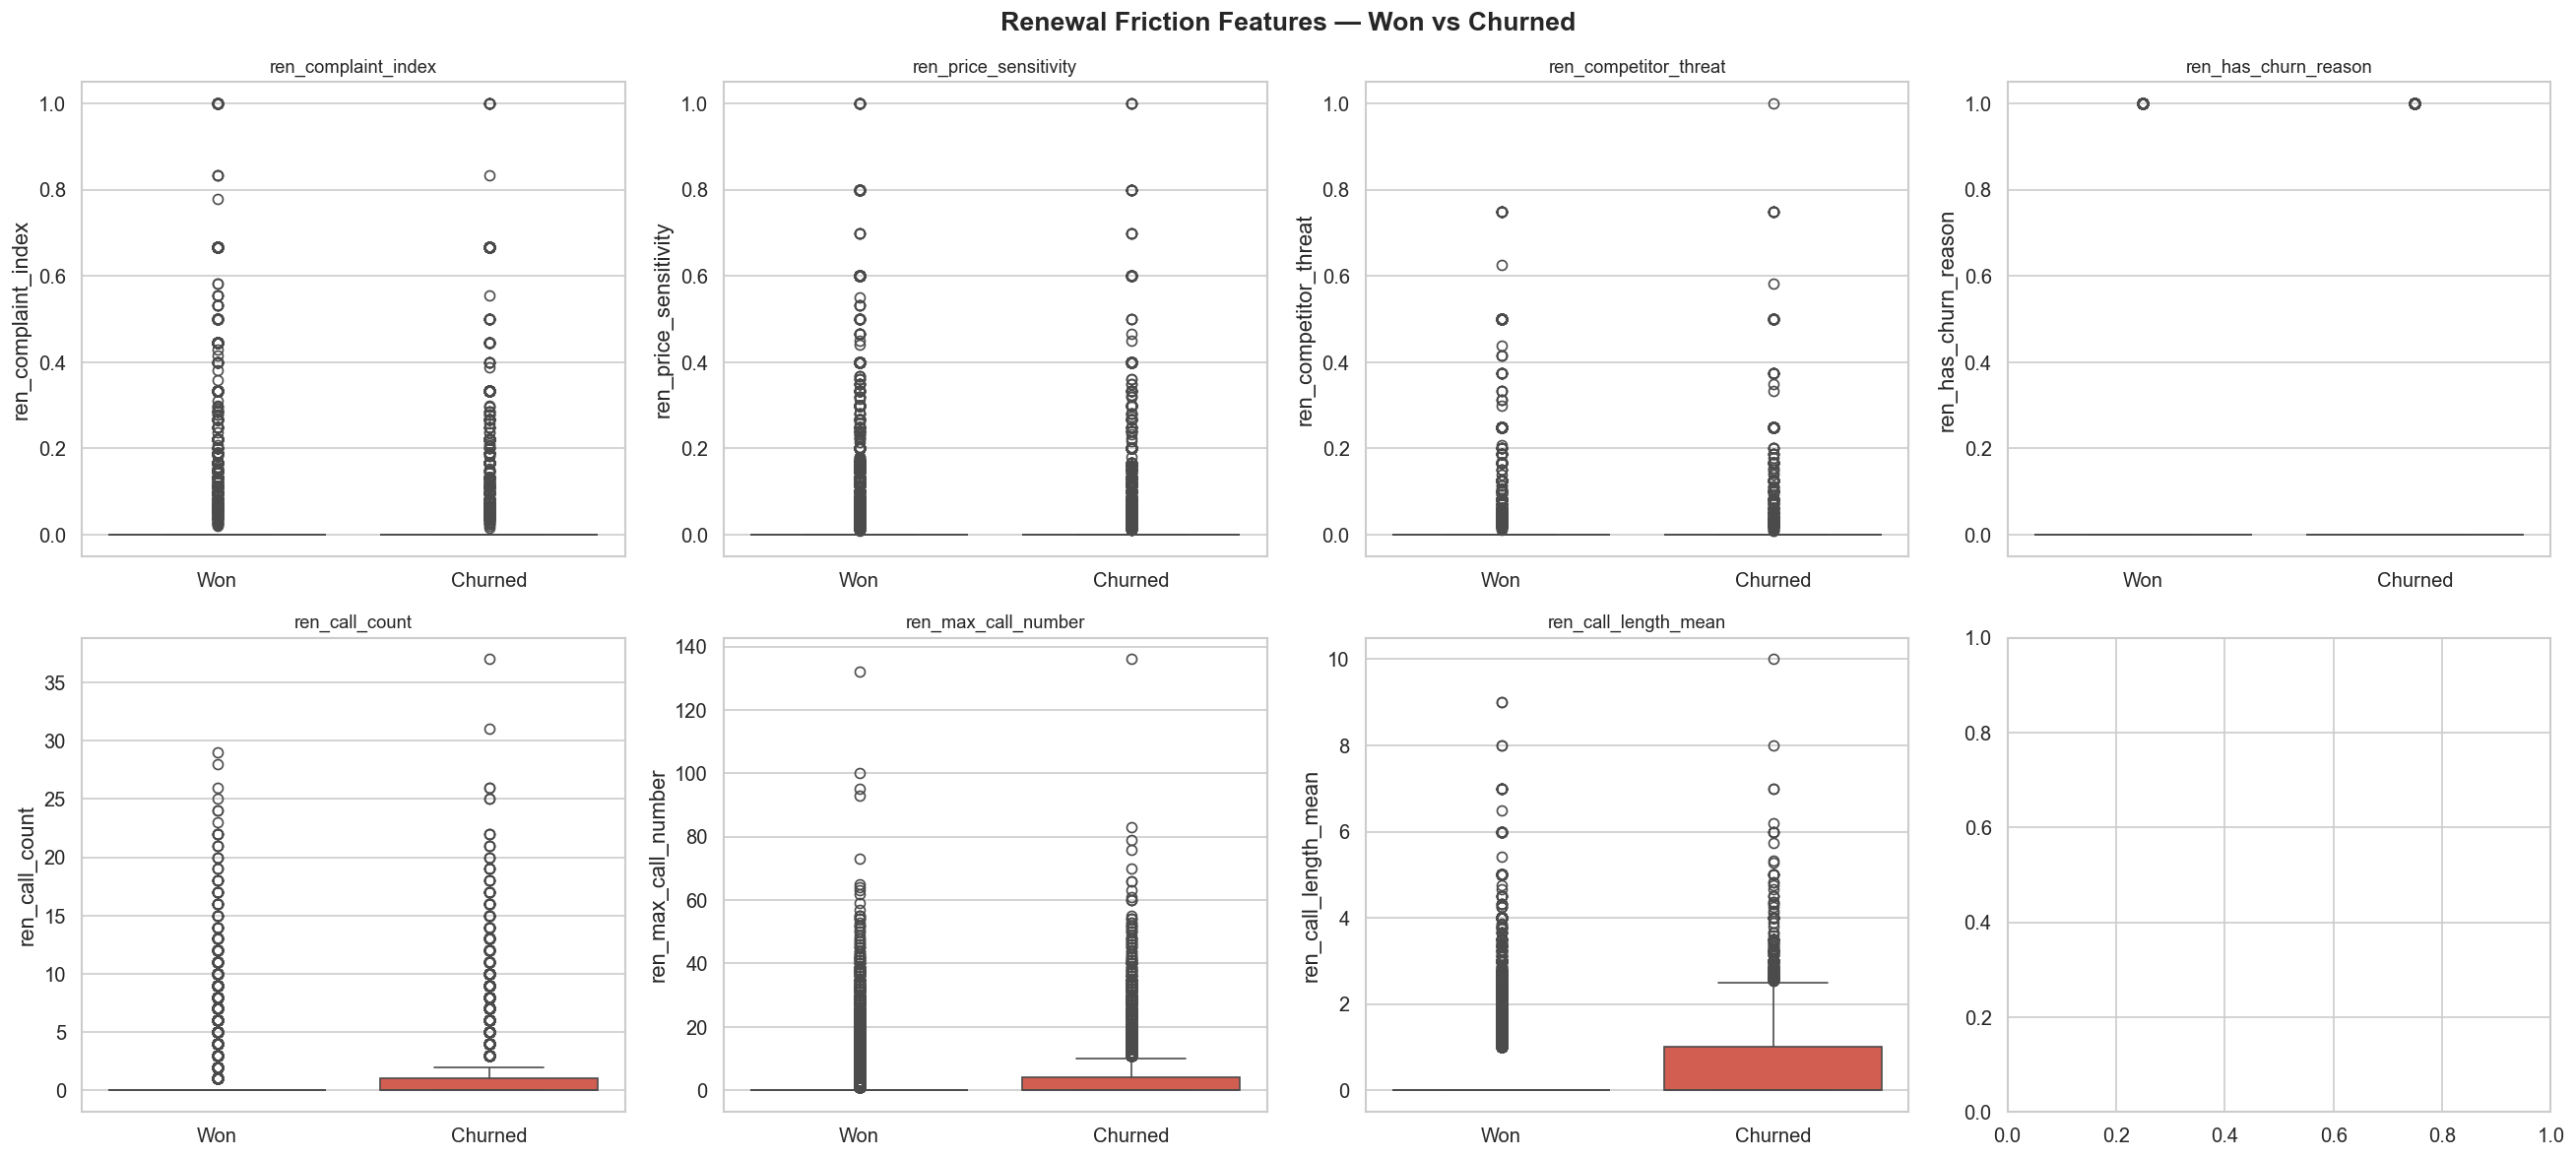

In [5]:
# --- renewal friction features ---
renewal_feats = [
     "ren_complaint_index",
    "ren_price_sensitivity", "ren_competitor_threat",
    "ren_has_churn_reason", "ren_call_count",
    "ren_max_call_number", "ren_call_length_mean",
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Renewal Friction Features — Won vs Churned", fontsize=16, fontweight="bold")

for ax, feat in zip(axes.flatten(), renewal_feats):
    sns.boxplot(data=df, x="Prospect_Outcome", y=feat, ax=ax,
                order=["Won", "Churned"], palette={"Won": "#2ecc71", "Churned": "#e74c3c"})
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

---
## 2 · Stacked Bar Charts — Categorical Features

For each categorical feature that passed the chi-square test,
we show the churn rate per category.

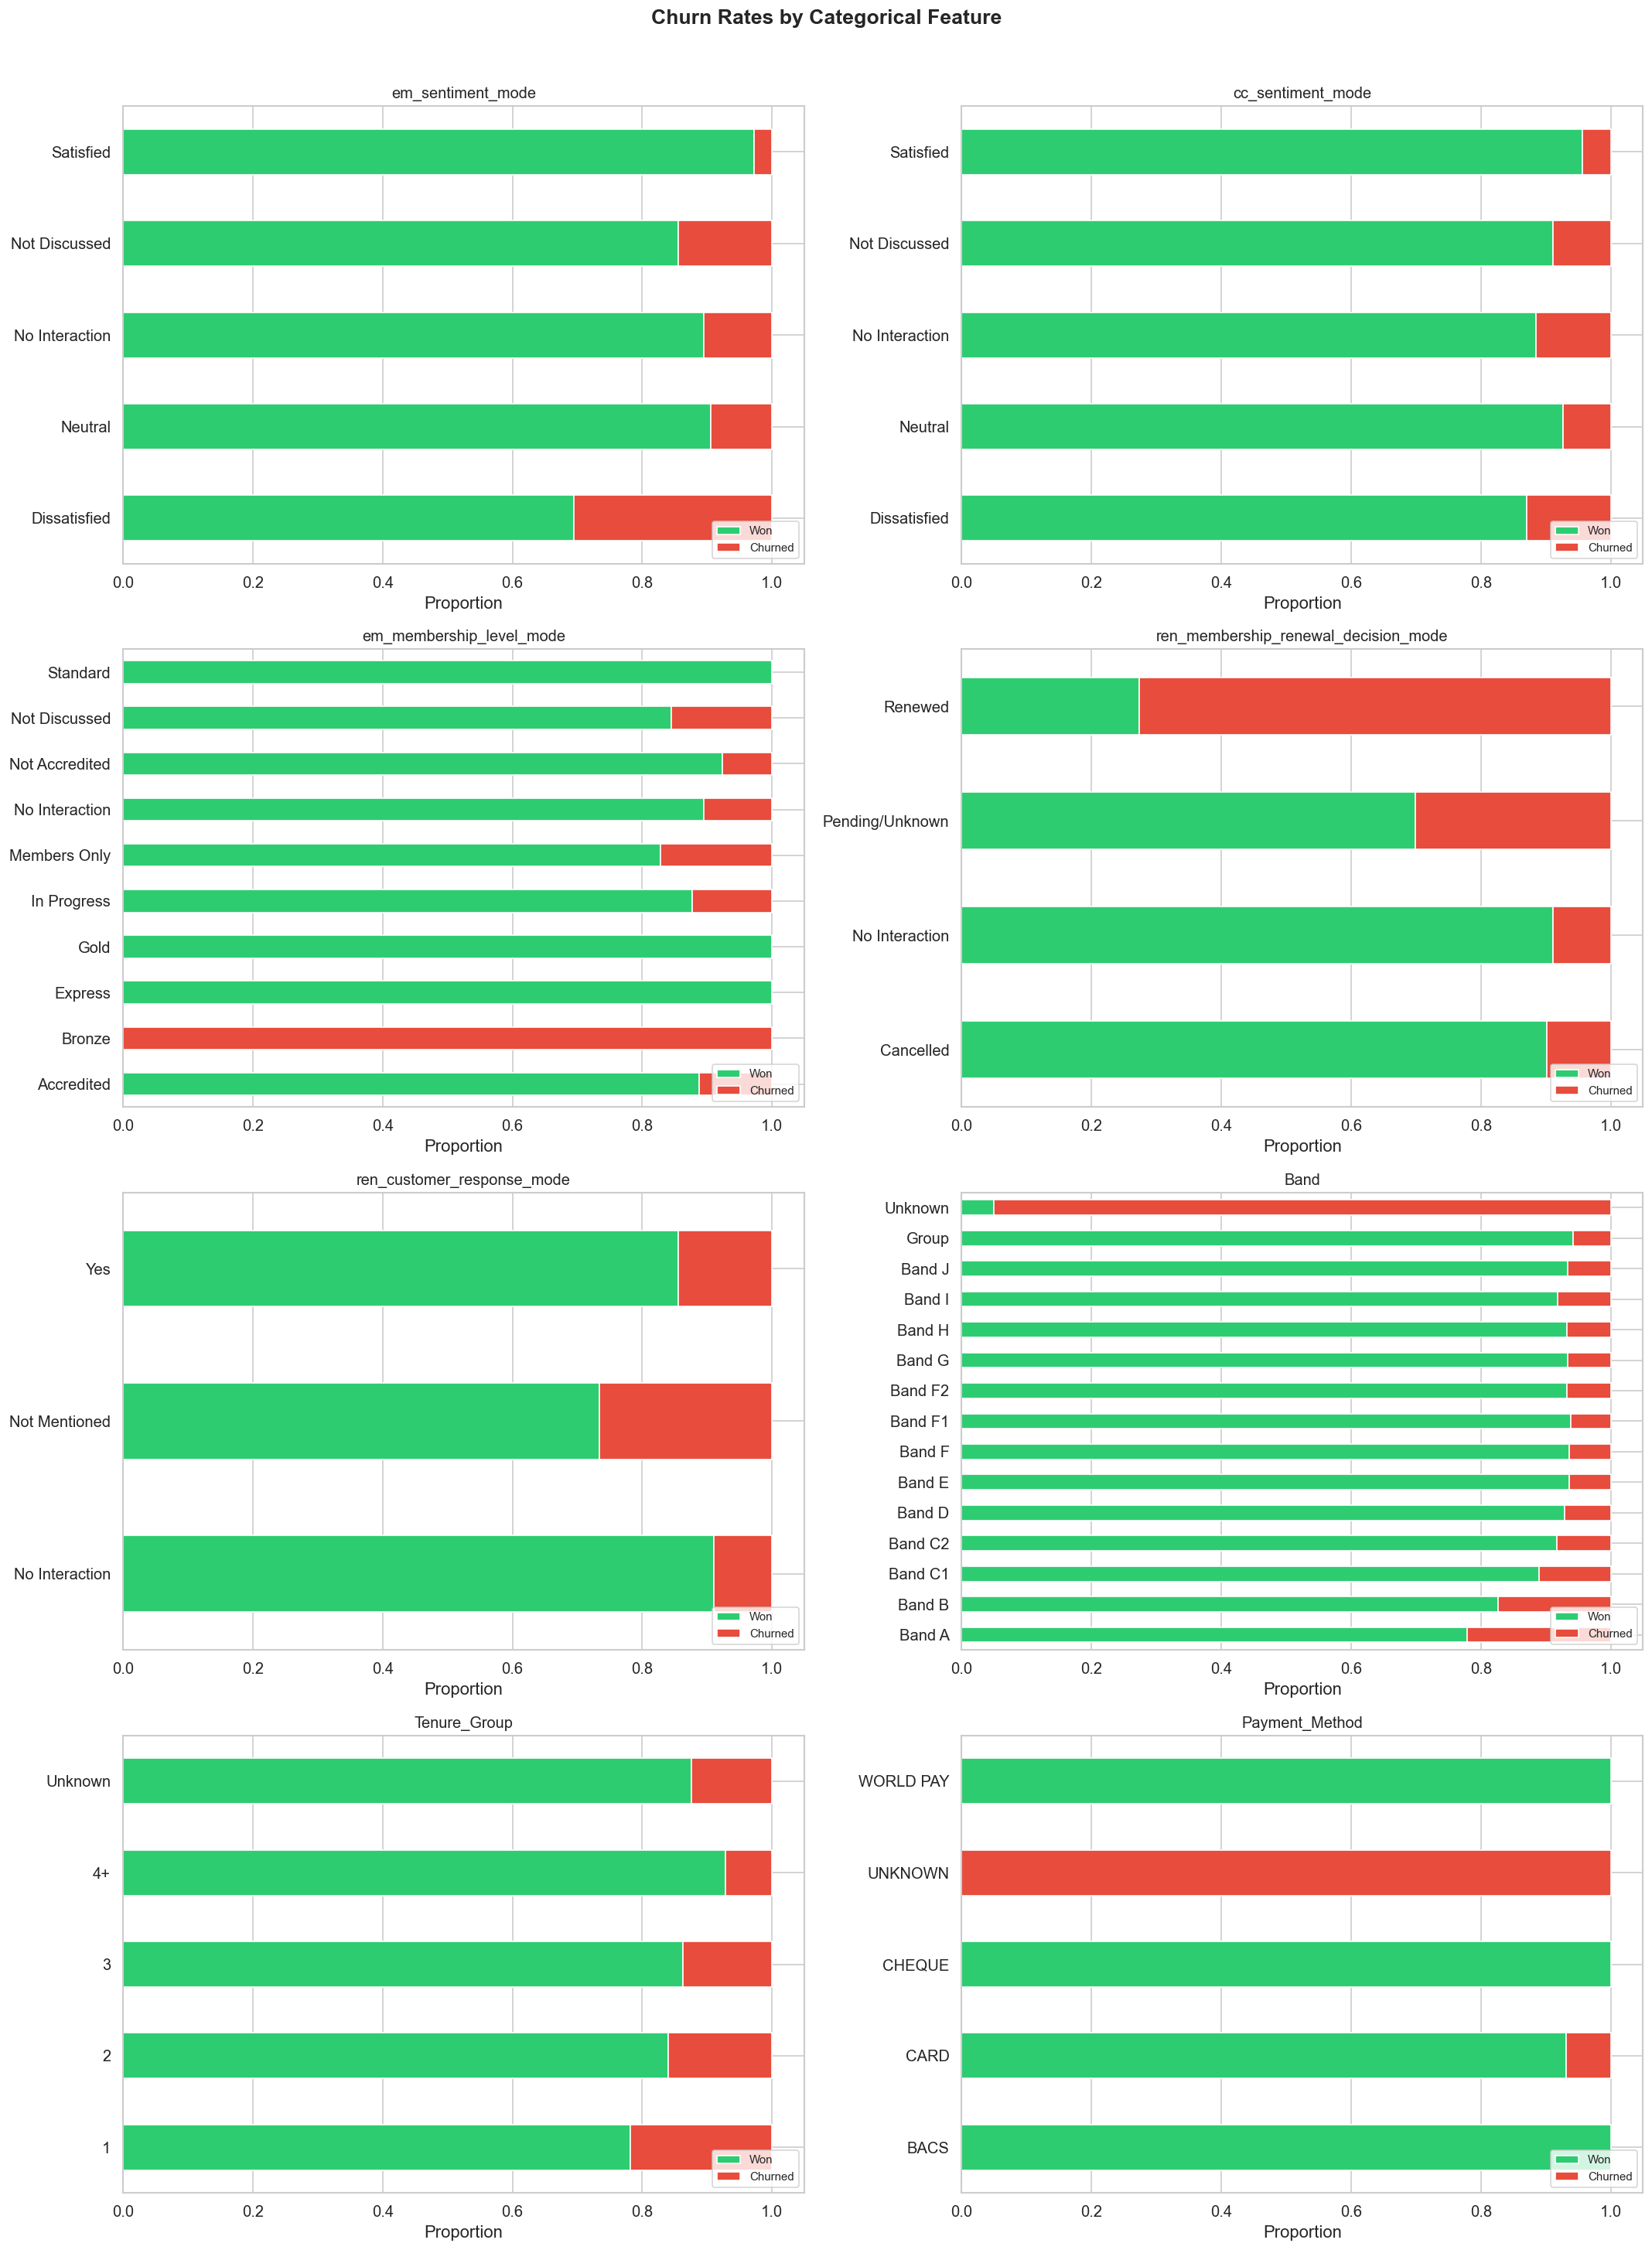

In [6]:
cat_feats = [
    "em_sentiment_mode", "cc_sentiment_mode",
    "em_membership_level_mode",
    "ren_membership_renewal_decision_mode", "ren_customer_response_mode",
    "Band", "Tenure_Group", "Payment_Method",
]

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
fig.suptitle("Churn Rates by Categorical Feature", fontsize=16, fontweight="bold", y=1.01)

for ax, feat in zip(axes.flatten(), cat_feats):
    ct = pd.crosstab(df[feat], df["Prospect_Outcome"], normalize="index")
    ct = ct[["Won", "Churned"]]  # order cols
    ct.plot.barh(stacked=True, ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="white")
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel("Proportion")
    ax.set_ylabel("")
    ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

---
## 3 · Feature Importance — Correlation with Churn

Horizontal bar chart of absolute correlations between numeric
features and the binary churn flag. This gives a quick view of
which features the model should lean on hardest.

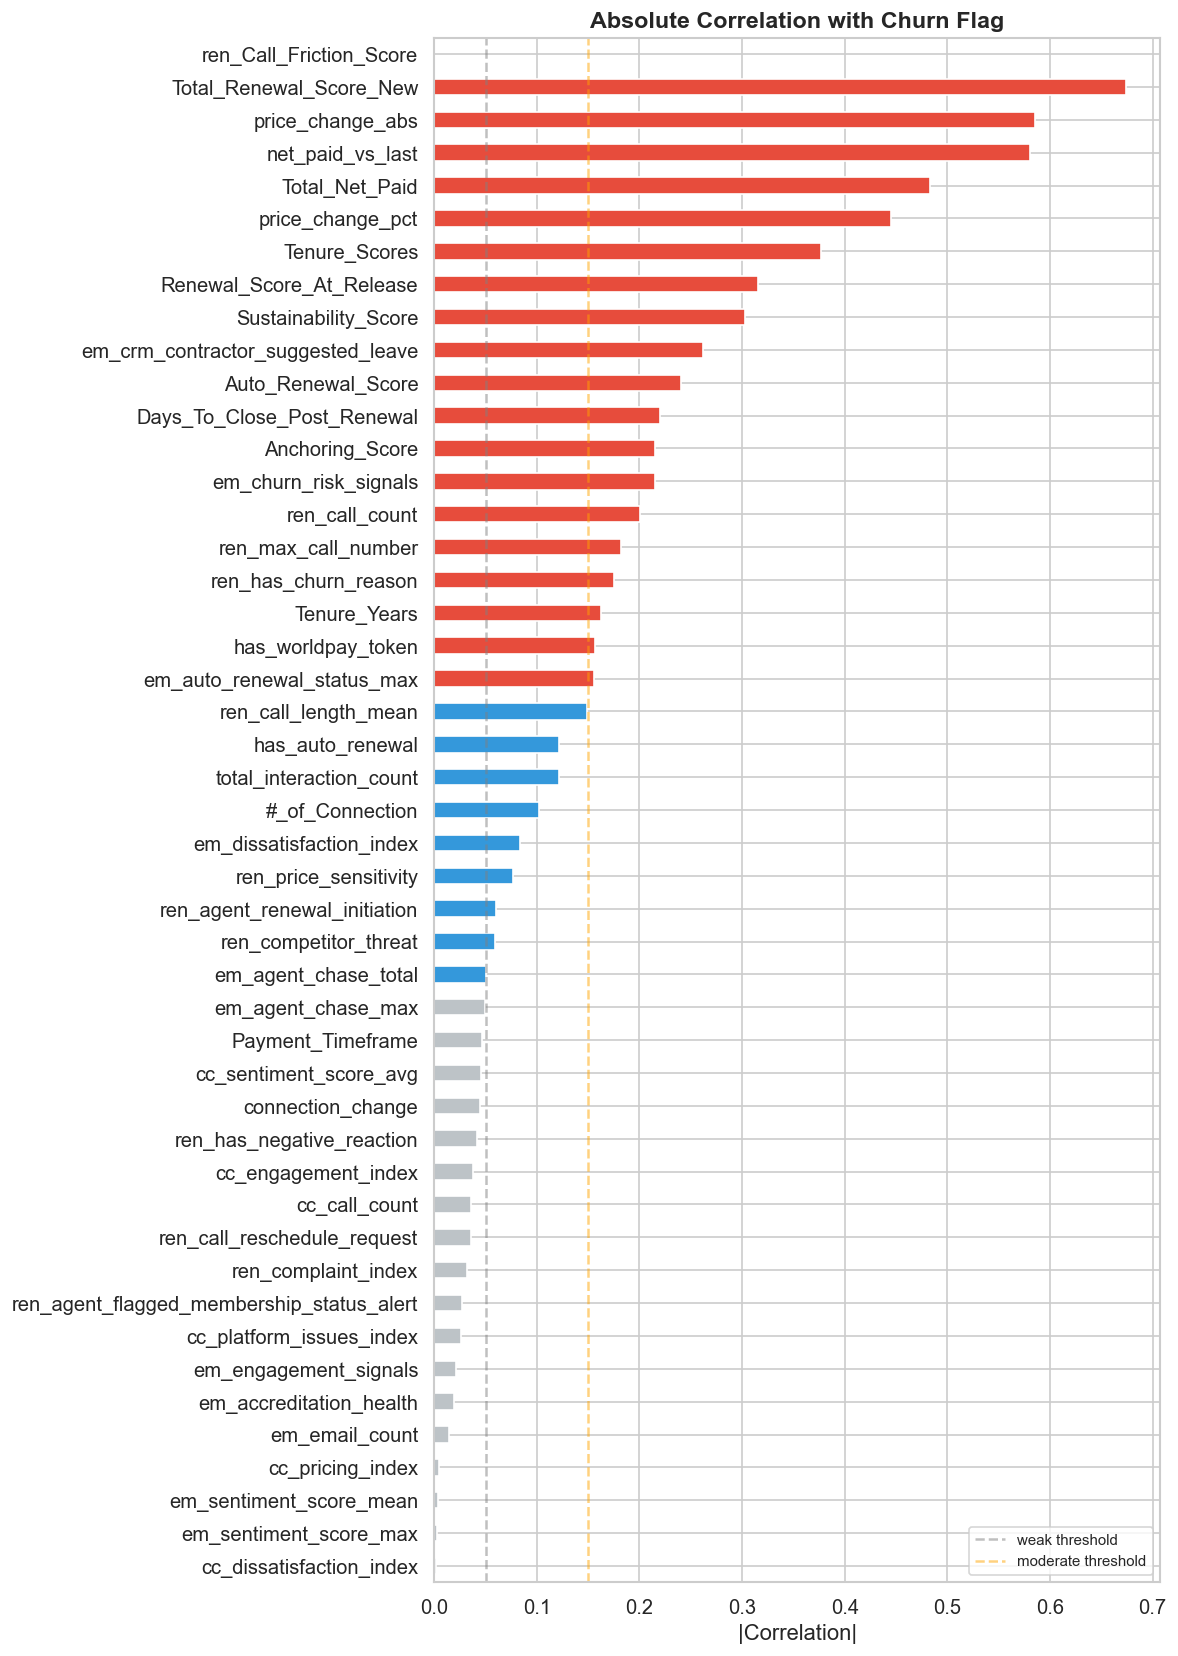

In [7]:
df["churn_flag"] = (df["Prospect_Outcome"] == "Churned").astype(int)

num_cols = df.select_dtypes(include=[np.number]).columns.drop(["churn_flag", "Renewal_Year"], errors="ignore")
corrs = df[num_cols].corrwith(df["churn_flag"]).abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
colors = ["#e74c3c" if v > 0.15 else "#3498db" if v > 0.05 else "#bdc3c7" for v in corrs.values]
corrs.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set_title("Absolute Correlation with Churn Flag", fontsize=14, fontweight="bold")
ax.set_xlabel("|Correlation|")
ax.axvline(x=0.05, color="gray", linestyle="--", alpha=0.5, label="weak threshold")
ax.axvline(x=0.15, color="orange", linestyle="--", alpha=0.5, label="moderate threshold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

df.drop(columns=["churn_flag"], inplace=True)

---
## 4 · Violin Plots — Top 6 Strongest Predictors

For the six features with the highest absolute correlation to churn,
violin plots show the full distribution shape.

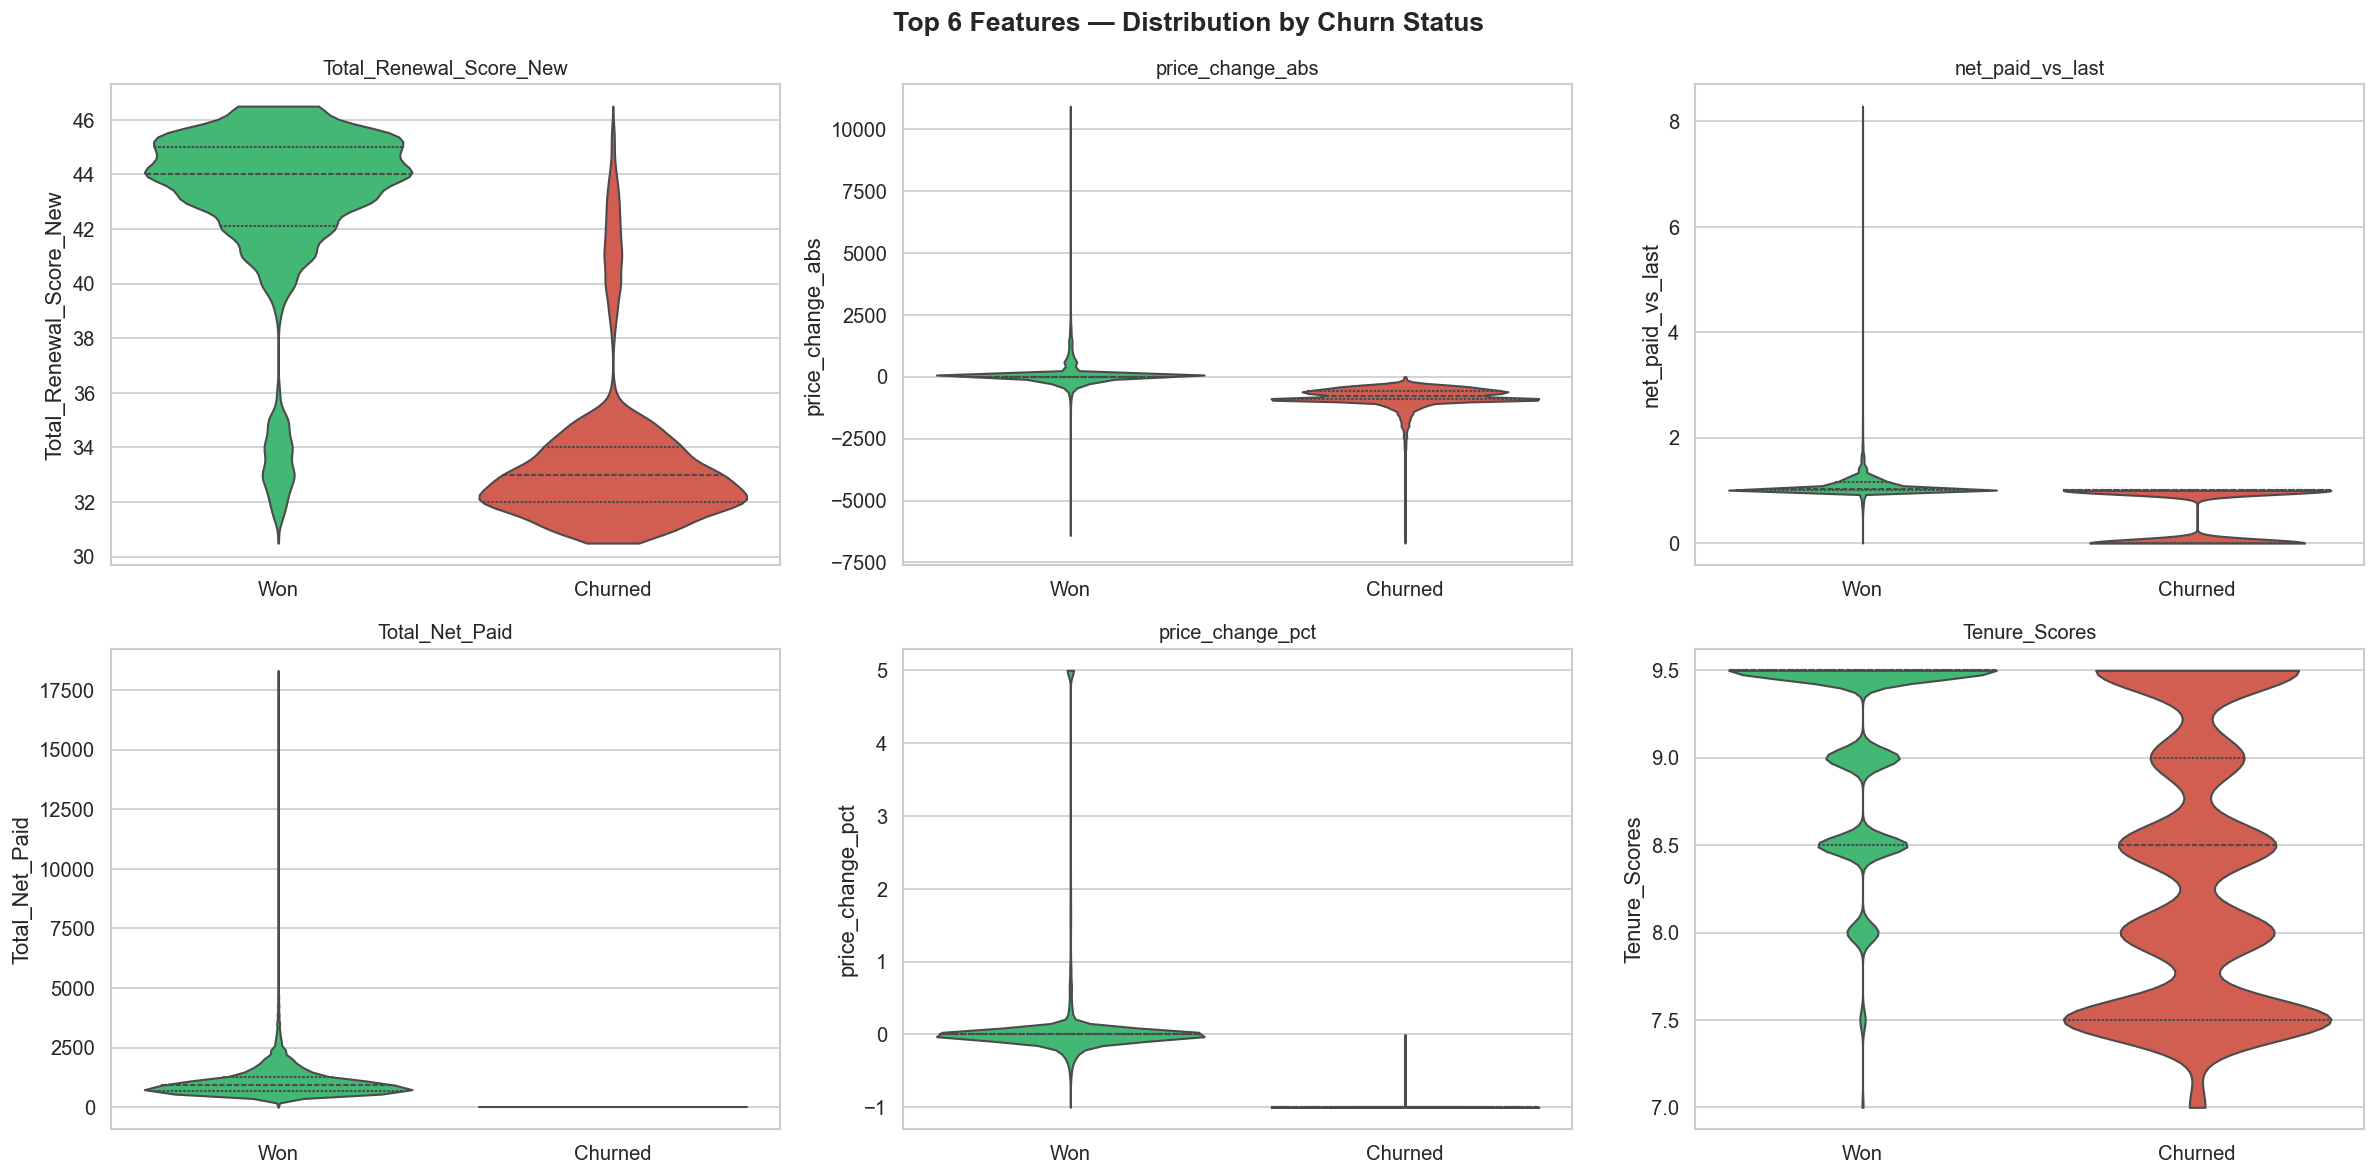

In [8]:
top6 = [
    "Total_Renewal_Score_New", "price_change_abs",
    "net_paid_vs_last", "Total_Net_Paid",
    "price_change_pct", "Tenure_Scores",
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Top 6 Features — Distribution by Churn Status", fontsize=16, fontweight="bold")

for ax, feat in zip(axes.flatten(), top6):
    sns.violinplot(data=df, x="Prospect_Outcome", y=feat, ax=ax,
                   order=["Won", "Churned"],
                   palette={"Won": "#2ecc71", "Churned": "#e74c3c"},
                   inner="quartile", cut=0)
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

---
## Summary

The visualizations confirm the hypothesis test results:

- **Billing scores** show the clearest separation between Won and Churned.
  `Total_Renewal_Score_New` alone has a correlation of ~0.67 with churn.
  The box/violin plots show almost non-overlapping distributions for this feature.

- **Price-change features** (`price_change_abs`, `net_paid_vs_last`) are
  near-zero for retained customers but show wide variation for churned ones.

- **Churn risk signals** from email data (`em_churn_risk_signals`,
  `em_crm_contractor_suggested_leave`) are visually striking — churned
  customers have much higher medians.

- Among **categorical features**, `em_sentiment_mode` is the most
  discriminating: 'Dissatisfied' customers churn at ~30%, while
  'Satisfied' customers churn at only ~3%.

- **Renewal friction** features confirm that post-renewal call patterns
  (friction, complaints, call counts) are strong signals of eventual churn.

These insights will directly inform feature selection and model training
in the next phase of the project.